# Classification

<img src="./img/5_classification_vs_regression_graph.png" width="700px"><br><br>

With `Regression` we tried to find the hyperplane that __best fits__ (represents) the data.

With `Classification` we want to find the hyperplane that __best separates__ data into similar categories.

# kNN Classifier (k-nearest Neighbours)

##### Assumption:

> <br>  
> Adjacent nodes are similar<br><br>  
> <b>"distance"</b> can be computed
> <br><br>

<br><br>
<img src="./img/5_kNN.png">

<span style="font-size: 70%">Given a labled dataset, a new data point needs to be classified (<b>top left</b>). The distance to a predefined <br>number of neighbours is calculated and the class assigned according to the sum of distances <br>of each class (<b>top right</b>). Only neighbours in a respective radius are considered (<b>bottom</b>).</span>

<br>
<img src="./img/5_kNN_3.png" width="300px">

<span style="font-size: 70%"><b>Note:</b> The value of $k$ determines the class. Changing $k$ may change the class a data point is voted to.<br>In this example a value of $k = 3$ makes the green dot belong to the class of red triangles (<b>inner circle</b>), <br>$k = 5$ assigns the class of blue squares (<b>outer dotted circle</b>).</span>

##### Calculating distances:

Given data of order $p$:

$X = \left ( x_1, x_2, \dots , x_n \right)$ and $Y = \left ( y_1, y_2, \dots , y_n \right) \epsilon \  \mathbb{R}^2$

<br>

the `Minkowski distance` is defined as:

$D \left( X, Y \right) = \left( \sum_{i=1}^{n} {\left| x_i - y_i \right|}^p \right)^{\frac{1}{p}}$ for $p \ge 1$

<br>

For $p = 1$:

$D \left( X, Y \right) = \sum_{i=1}^{n} {\left| x_i - y_i \right|} $ &nbsp;&nbsp; $ \dots $ `Manhattan distance`

<br>

for $p = 2$:

$D \left( X, Y \right) = \sqrt {\left( \sum_{i=1}^{n} {\left| x_i - y_i \right|}^2 \right) }$ &nbsp;&nbsp; $ \dots $ `Euclidian distance`
<br><br>

<img src="./img/5_minkowski.png" width="1000px">

<span style="font-size: 70%">Unit circles (distance from the centre) for various <i>p</i>.<br>Source: <a href="https://en.wikipedia.org/wiki/Minkowski_distance">Wikipedia</a></span>

<br><br>

<table>
<tr>
<td style="border-style: none"><img src="./img/0_reference.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><u>Further reading:</u>
<ul>
<li>To get a glimpse of the underlying implementation, you may want to read Chapter 12 in the book "<b>Data Science from Scratch</b>"</li>
<li>For a primer with <b>scikit-learn</b> refer to <a href="https://scikit-learn.org/stable/modules/neighbors.html#nearest-neighbor-algorithms">the Scikit Learn documentation on Nearest Neighbours Classifiers</a></li>
<li>Scikit <a href="https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier">kNN Classifier</a></li>
</ul>
</td>
</tr>
</table>

### Get acquainted with your data - The IRIS dataset

This is the original [Iris dataset](https://archive.ics.uci.edu/ml/datasets/iris).

However, we will use the [scikit-learn iris toy-set](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-plants-dataset) to see how to utilize the dataset loading facilities of scikit-learn.

##### Let's take a look at what we have and what it means

__Attribute Information:__

1. sepal length \[cm\]
2. sepal width \[cm\]
3. petal length \[cm\]
4. petal width \[cm\]
5. class:
 - Iris Setosa (setosa)
 - Iris Versicolour (versicolor)
 - Iris Virginica (virginica)
 
Total data records: 150 (50/species)

<br><br>

__What they look like:__

<img src="https://upload.wikimedia.org/wikipedia/commons/7/78/Petal-sepal.jpg" width="400px"><br>
<span style="font-size: 70%">Figure 1: Sepal (protective outer sheet) and Petal (blossom leaves)</span>
<br><br>

<table style="align: left; padding: 0; border-style: none">
    <tr style="border-style: none">
        <td style="border-style: none">
            <img src="https://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg" height="180px">
        </td>
        <td style="border-style: none">
            <img src="https://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg" height="180px">
        </td>
        <td style="border-style: none">
            <img src="https://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg" height="180px">
        </td>
    </tr>
    <tr style="border-style: none">
        <td style="border-style: none">Setosa</td>
        <td style="border-style: none">Versicolour</td>
        <td style="border-style: none">Virginica</td>
    <tr>
</table>
<span style="font-size: 70%">Figure 2: Different species of irises (classes) in the dataset</span>


### Let's get coding

In [45]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score


In [46]:
# prepare the data
iris = load_iris()

In [47]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [48]:
# create a dataframe for statistic evaluation
feature_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
df = pd.DataFrame(iris.data, columns=feature_columns)

# we could do this
# df['class'] = pd.Series(iris.target)
# or use the LabelEncoder

df['Species'] = pd.Series(iris.target_names[iris.target])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [49]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


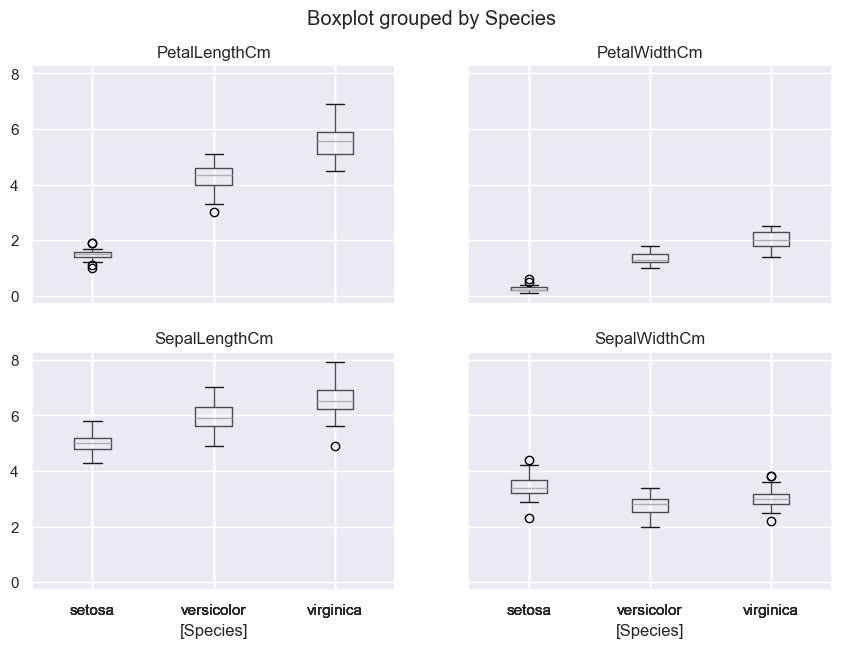

In [50]:
# check distribution
df.boxplot(by="Species", figsize=(10,7))
plt.show()

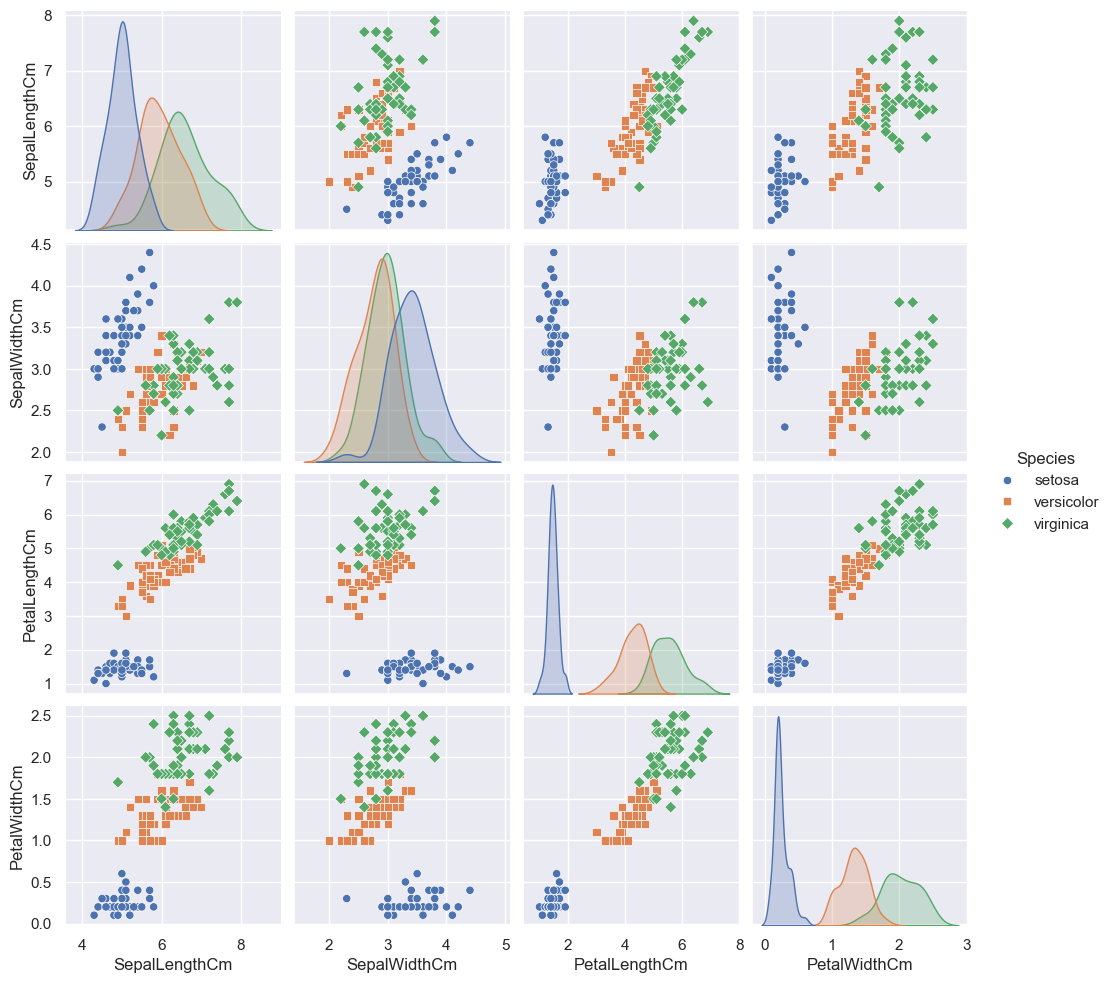

In [51]:
sns.set_theme(style='darkgrid')
g = sns.pairplot(df, hue='Species', markers=["o", "s", "D"])

In [52]:
# prepare data for model building with scikit-learn

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [53]:
# model generation
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [54]:
# predict
y_pred = clf.predict(X_test)

Evaluate model quality

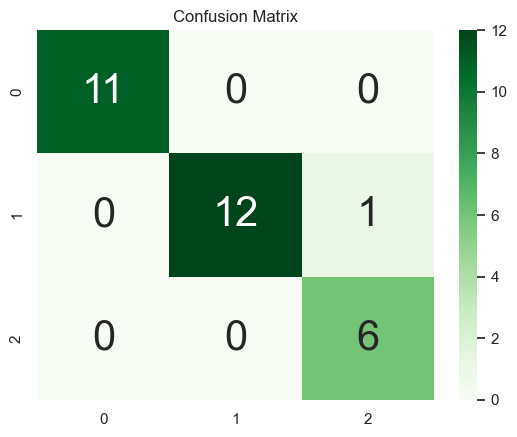

In [55]:
# generate a confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

# visualize the confusion matrix
ax = plt.axes()
sns.heatmap(cm, annot=True, annot_kws={"size": 30}, cmap="Greens", ax=ax)
ax.set_title('Confusion Matrix')
plt.show()

In [56]:
accuracy = accuracy_score(y_test, y_pred)*100
print(f'Accuracy of our model is equal {str(round(accuracy, 2))} %.')


Accuracy of our model is equal 96.67 %.


### How does the model decide?
(drawing decision boundaries)

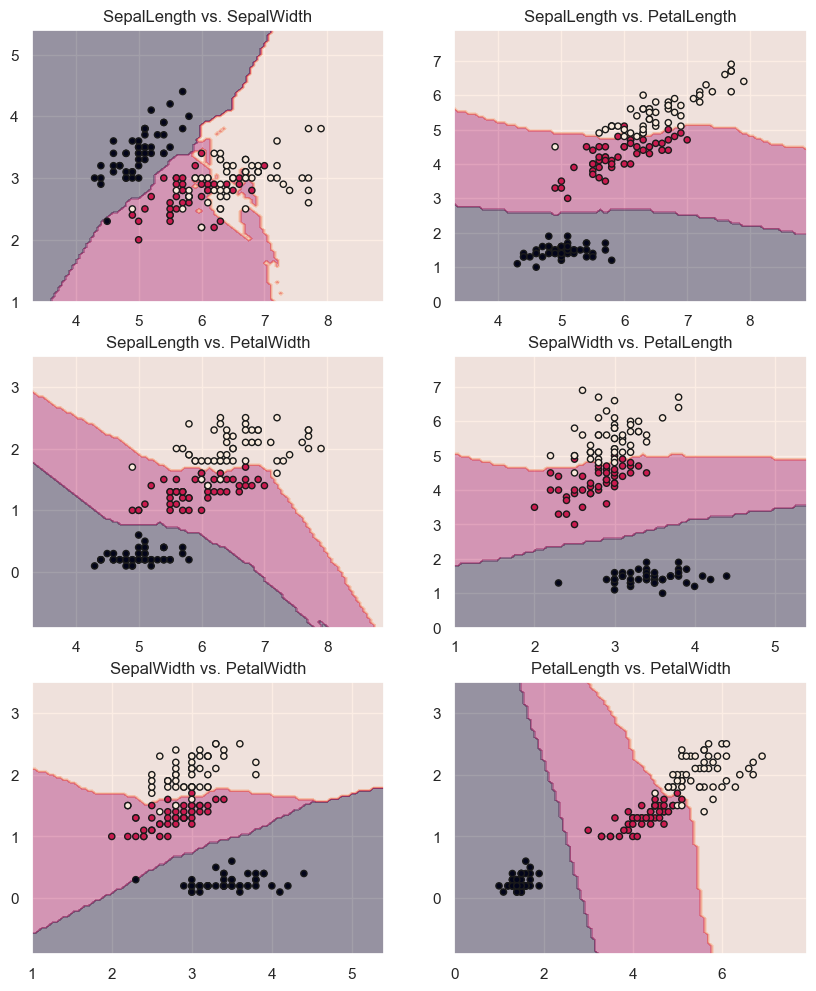

In [57]:
# only needed for display of decission boundaries
from itertools import product
from sklearn.inspection import DecisionBoundaryDisplay

# all combinations to compare
X_cols_combo = [["SepalLengthCm", "SepalWidthCm"], ["SepalLengthCm", "PetalLengthCm"],
                ["SepalLengthCm", "PetalWidthCm"], ["SepalWidthCm", "PetalLengthCm"],
                ["SepalWidthCm", "PetalWidthCm"], ["PetalLengthCm", "PetalWidthCm"]]

# comparing datasets
X1 = df[X_cols_combo[0]].to_numpy()
X2 = df[X_cols_combo[1]].to_numpy()
X3 = df[X_cols_combo[2]].to_numpy()
X4 = df[X_cols_combo[3]].to_numpy()
X5 = df[X_cols_combo[4]].to_numpy()
X6 = df[X_cols_combo[5]].to_numpy()
y = iris.target

# generating a forrest of classifiers
clf_1 = KNeighborsClassifier(n_neighbors=7)
clf_2 = KNeighborsClassifier(n_neighbors=7)
clf_3 = KNeighborsClassifier(n_neighbors=7)
clf_4 = KNeighborsClassifier(n_neighbors=7)
clf_5 = KNeighborsClassifier(n_neighbors=7)
clf_6 = KNeighborsClassifier(n_neighbors=7)

# make things iterable
clf_all = [clf_1, clf_2, clf_3, clf_4, clf_5, clf_6]
X_sets = [X1, X2, X3, X4, X5, X6]

# helper to generate the image position
img_pos = [pos_t for pos_t in product([0, 1, 2], [0, 1])]

f, ax = plt.subplots(3, 2, figsize=(10, 12))

for i, classifier in enumerate(clf_all):
    classifier.fit(X_sets[i], y)
    DecisionBoundaryDisplay.from_estimator(classifier, X_sets[i], alpha=0.4, ax=ax[img_pos[i][0], img_pos[i][1]], response_method="predict")
    ax[img_pos[i][0], img_pos[i][1]].scatter(X_sets[i][:, 0], X_sets[i][:, 1], c=y, s=20, edgecolor="k")
    ax[img_pos[i][0], img_pos[i][1]].set_title(f"{X_cols_combo[i][0][:-2]} vs. {X_cols_combo[i][1][:-2]}")



### Evaluation of the implementation

In the book only a very simple algorithm based on Euclidian distance was implemented.

Using `Scikit-learn` has several benefits:

- selection of optimal algorithms based on the characteristics of the dataset (ref. discussion of BruteForce, Ball Tree vs. KD Tree in the [online documentation](https://scikit-learn.org/stable/modules/neighbors.html#nearest-neighbor-algorithms))
- algorithmic handling of sparse and dense datasets (one does not have to correct NaN data)
- adjustable calculation of metrics (specifically using RadiusNeighborsClassifier in case none-uniform distribution)
- parameterized calculation cost (ref. discussion on leaf_size)

Some things to keep in mind:

- In rare cases, the order of data can determine the class of a data point

<br>

# Curse of Dimensionality

`k-Nearest Neighbour` as demonstrated in the book is susceptible to the `Curse of Dimensionality`.

__Briefly explained:__

With every dimension added to the data (and that implies, with every added feature), 

- computation time increases by an order $O \left( N \right)$
- data density decreases
- distance between data points grows
- which leads to a spread between closest to average distances (making the range of data computationally complex)

<table>
<tr>
<td style="border-style: none"><img src="./img/0_students_input.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><h5>Students task: Discuss</h5>
<ul>
    <li>How would an algorithm have to be designed so that it is not vulnerable to this phenomenon?</li>
    <li>Considering technological advances (in computing power), is this even an issue?</li>
</ul>
</td>
</tr>
</table>

<table>
<tr>
<td style="border-style: none"><img src="./img/0_reference.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><u>Further reading:</u>
<ul>
<li>Read Chapter 12, pages 223 - 228 in the book "<b>Data Science from Scratch</b>"</li>
<li><a href="https://builtin.com/data-science/curse-dimensionality">What Is the Curse of Dimensionality?</a> (also available in the material section)</li>
</ul>
</td>
</tr>
</table>